<a href="https://colab.research.google.com/github/kamranbb-29/personal-finance-tracker/blob/main/Insuarance_LR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

import numpy as np


from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression





# Dataset


In [ ]:
df=pd.read_csv("sample_data/insurance.csv")
df







,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# EDA


##Gender Analysis

In [ ]:
male=df[df['sex']=="male"]



female=df[df['sex']=="female"]
male.describe()

,age,bmi,children,charges
count,676.000000,676.000000,676.000000,676.000000
mean,38.917160,30.943129,1.115385,13956.751178
std,14.050141,6.140435,1.218986,12971.025915
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.410000,0.000000,4619.134000
50%,39.000000,30.687500,1.000000,9369.615750
75%,51.000000,34.992500,2.000000,18989.590250
max,64.000000,53.130000,5.000000,62592.873090


###Observation

Males and females are almost equal 676 and 662 and their cost averages don't have much difference

###Interpretation

Gender doesn't have much influence on medical cost expense

##Smoker Analysis

In [ ]:
smoker=df[df['smoker']=="yes"]
meanChargesSmoker=smoker['charges'].mean()

non_smoker=df[df['smoker']=="no"]


meanChargesNonSmoker=non_smoker['charges'].mean()


male=df[df['sex']=="male"]




female=df[df['sex']=="female"]




maleSmoker=male[male['smoker']=="yes"]
femaleSmoker=female[female['smoker']=="yes"]

###Observation

Smokers have a higher medical cost as compared with non smokers, also male smokers also have a higher medical cost as compared with female smokers but the percentage of female smokers is lesser than male smokers, female smoker=17% whereas male smokers=23%

###Interpretation

Smoking increases medical cost as we know smoking deteriorates health

##Children Analysis

In [ ]:
female_with_children=female[female['children']>=1]
female_with_children.describe()

female_without_children=female[female['children']==0]
female_without_children.describe()


,age,bmi,children,charges
count,289.000000,289.000000,289.0,289.000000
mean,38.346021,30.361522,0.0,11905.714276
std,16.358335,5.966934,0.0,11471.881191
min,18.000000,17.290000,0.0,1607.510100
25%,22.000000,26.200000,0.0,3171.614900
50%,36.000000,29.925000,0.0,9541.695550
75%,56.000000,34.600000,0.0,14133.037750
max,64.000000,47.410000,0.0,63770.428010


###Observation

Females with children have more avg medical cost than those without children but the number of females with children are higher than those without children

###Interpretation

Having a child does have a little effect on insuarance cost but not of that significance

##Age Analysis

In [ ]:
df['age'].describe()

above_mean = df[df['age'] > df['age'].mean()]
below_mean = df[df['age'] <= df['age'].mean()]

above_mean.describe()
below_mean.describe()


,age,bmi,children,charges
count,674.000000,674.000000,674.000000,674.000000
mean,27.048961,30.074941,1.063798,10157.217581
std,6.713118,6.243012,1.228837,11647.688388
min,18.000000,15.960000,0.000000,1121.873900
25%,21.000000,25.800000,0.000000,2719.790013
50%,27.000000,29.805000,1.000000,4749.061450
75%,33.000000,34.103750,2.000000,15743.034337
max,39.000000,53.130000,5.000000,58571.074480


###Observation

The number of people above and below the mean age is almost the same.
However, people above the mean age have a significantly higher average insurance cost.

###Interpretation

As age increases, insurance charges also tend to increase. This suggests that age has a positive relationship with medical insurance expenses.

##BMI Analysis

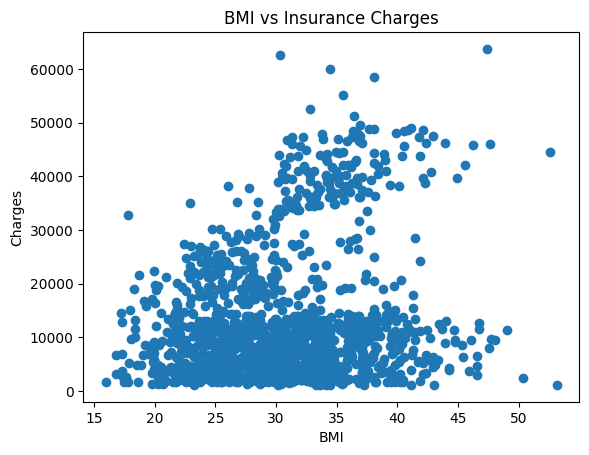

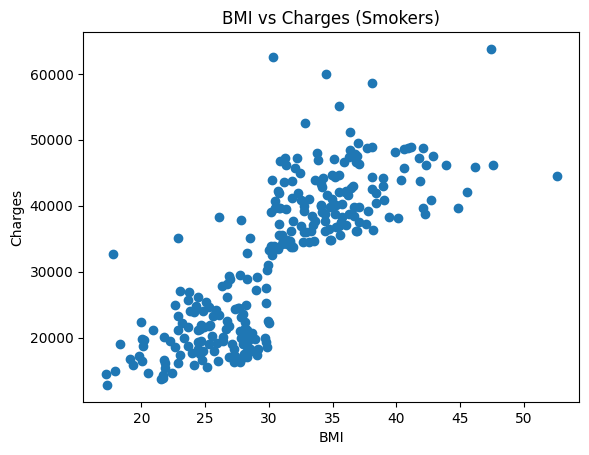

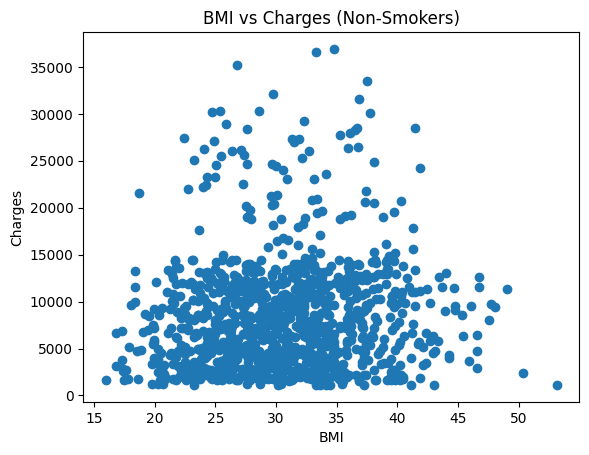

np.float64(30.074940652818988)

In [ ]:
# Overall BMI vs Charges Scatter Plot
plt.scatter(df['bmi'], df['charges'])
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.title("BMI vs Insurance Charges")
plt.show()

# Smokers
smoker_df = df[df['smoker'] == "yes"]

plt.scatter(smoker_df['bmi'], smoker_df['charges'])
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.title("BMI vs Charges (Smokers)")
plt.show()

# Non-Smokers
non_smoker_df = df[df['smoker'] == "no"]

plt.scatter(non_smoker_df['bmi'], non_smoker_df['charges'])
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.title("BMI vs Charges (Non-Smokers)")
plt.show()

# Average BMI above and below mean age

above_mean = df[df['age'] > df['age'].mean()]
below_mean = df[df['age'] <= df['age'].mean()]

above_mean['bmi'].mean()
below_mean['bmi'].mean()

###Observation

The overall BMI vs Charges scatter plot does not show a strong linear relationship.
Among non-smokers, BMI has very little effect on insurance charges.
Among smokers, insurance charges tend to increase as BMI increases.
Approximately 73 smokers were concentrated in the BMI range 30–35.
Average BMI for people above and below the mean age is almost the same.

###Interpretation

BMI alone is not a strong predictor of insurance charges. However, among smokers, higher BMI appears to be associated with higher medical expenses. This suggests that smoking may amplify the effect of BMI on insurance costs.

# Feature Engineering




##Binary Encoding

In [ ]:
df['sex'] = df['sex'].map({'male': 0, 'female': 1})

df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})

##One Hot Encoding

In [ ]:
region_df = pd.get_dummies(df['region'], drop_first=True)

df = pd.concat([df, region_df], axis=1)
df = df.drop('region', axis=1)

###Separating features(X and Y)

In [ ]:
x=df.drop('charges',axis=1)
y=df['charges']

###Train Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=12)
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(1070, 8)
(268, 8)
(1070,)
(268,)


###

# My Linear Regression Class

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=12)

X_train = X_train.astype(int)
X_test = X_test.astype(int)


class MyLinearRegression:
    def __init__(self):
        self.beta=None

    def fit(self,X_train,y_train):
      X_test['intercept']=1;
      X_train['intercept']=1;
      X_train=X_train.to_numpy()

      y_train=y_train.to_numpy()


      X_transpose=X_train.T
      XTX=np.dot(X_transpose,X_train)
      XTX_inv=np.linalg.inv(XTX)
      XTY=np.dot(X_transpose,y_train)
      beta = np.dot(XTX_inv, XTY)
      self.beta=beta



    def predict(self,X_test):
        return np.dot(X_test,self.beta)















# Training

In [ ]:
lr=LinearRegression()


lr.fit(X_train,y_train)
predicted=lr.predict(X_test)
actual=y_test.to_numpy()

# Evaluation

In [ ]:
mae=np.mean(np.abs(predicted-actual))
mse=np.mean((predicted-actual)**2)

rmse=np.sqrt(mse)
SST=np.mean((actual-np.mean(actual))**2)
SSE=np.mean((actual-predicted)**2)

r2score=1-SSE/SST

r2score

print(r2_score(actual, predicted))

0.7104412366992795


##Gradient Descent